In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from factor_analyzer import FactorAnalyzer
from sklearn.linear_model import Lasso
traits = {
    'cOPN': 'Openness',
    'cEXT': 'Extraversion',
    'cNEU': 'Neuroticism',
    'cAGR': 'Agreeableness',	
    'cCON': 'Conscientiousness'
}
# rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1

In [8]:
## cronbach alpha
# pca_dim = 3
lasso_alpha = 0.3
savefig = True

for target in traits:
    ldf = pd.read_csv(f'filter/{target}_ldf.csv')
    emb_np = np.load(f'filter/{target}_emb.npy') 

    scaler = StandardScaler()
    esdf = scaler.fit_transform(emb_np)
    lsdf = scaler.fit_transform(ldf)
    # print(eedf.shape, ldf.shape, target)
    pca = PCA(n_components=None)
    re = pca.fit_transform(esdf)
    redf = pd.DataFrame(re)
    redf.columns = [f'pca_{i}' for i in range(redf.shape[1])]

    eedf = pd.DataFrame(esdf)
    eedf.columns = [f'e_{i}' for i in range(1536)]
    lsdf = pd.DataFrame(lsdf)
    lsdf.columns = [f'{l}' for l in ldf.columns]

    import pingouin as pg
    alpha_liwc = pg.cronbach_alpha(lsdf)
    # alpha_emb = pg.cronbach_alpha(redf)
    print(lsdf.shape, redf.shape)
    print(f'Cronbach\'s alpha for {target}: {alpha_liwc}')

(3635, 134) (3635, 1536)
Cronbach's alpha for cOPN: (0.6637411384440958, array([0.648, 0.679]))
(2363, 134) (2363, 1536)
Cronbach's alpha for cEXT: (0.6187154356717698, array([0.597, 0.64 ]))
(555, 134) (555, 555)
Cronbach's alpha for cNEU: (0.6376958477093122, array([0.594, 0.679]))
(2024, 134) (2024, 1536)
Cronbach's alpha for cAGR: (0.6476180569410122, array([0.625, 0.669]))
(1961, 134) (1961, 1536)
Cronbach's alpha for cCON: (0.5742894806444646, array([0.547, 0.601]))


/tmp/ipykernel_4143129/4002684650.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cdf.rename(columns={
/tmp/ipykernel_4143129/4002684650.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cdf2.rename(columns={


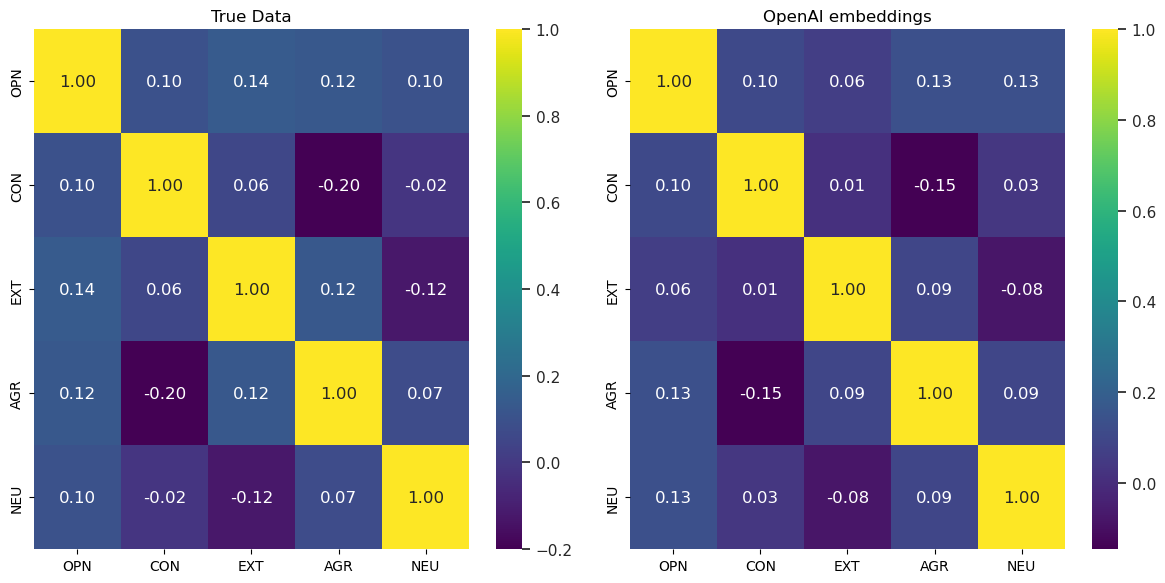

In [2]:
df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
cdf = df[['cOPN', 'cCON', 'cEXT', 'cAGR', 'cNEU']]
cdf.rename(columns={
    'cOPN': 'OPN',
    'cCON': 'CON',
    'cEXT': 'EXT',
    'cAGR': 'AGR',
    'cNEU' :'NEU'
}, inplace=True)

cdf2 = df[['mlp_cOPN', 'mlp_cCON', 'mlp_cEXT',  'mlp_cAGR', 'mlp_cNEU']]
cdf2.rename(columns={
    'mlp_cOPN': 'OPN',
    'mlp_cCON': 'CON',
    'mlp_cEXT': 'EXT',
    'mlp_cAGR': 'AGR',
    'mlp_cNEU' :'NEU'
}, inplace=True)

corr1 = cdf.corr()
corr2 = cdf2.corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.set_theme(style="whitegrid") 
sns.heatmap(corr1, annot=True, cmap='viridis', fmt='.2f', ax=axes[0])
axes[0].set_title('True Data')

sns.heatmap(corr2, annot=True, cmap='viridis', fmt='.2f', ax=axes[1])
axes[1].set_title('OpenAI embeddings')

# Adjust layout
plt.tight_layout()
plt.savefig(f'corre/correlation.png', bbox_inches='tight')
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load the model and tokenizer
model_name = "deepseekai/deepseek-base"  # Hypothetical model name
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Function to generate embeddings
def generate_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state[:, 0, :].squeeze()
    return embedding

# Example usage
text = "This is a sample text to generate embeddings."
embedding = generate_embedding(text)
print(embedding)

In [ ]:
# config = AutoConfig.from_pretrained("deepseek-ai/DeepSeek-R1", trust_remote_code=True)
# del config.quantization_config

# # config
# model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-R1", config=config, trust_remote_code=True)
# # Use a pipeline as a high-level helper
# from transformers import pipeline

# messages = [
#     {"role": "user", "content": "Who are you?"},
# ]
# from transformers import AutoModelForCausalLM, AutoConfig
# cache_dir  ="/data3/jm/hf_home/"
# config = AutoConfig.from_pretrained("deepseek-ai/DeepSeek-R1", 
# cache_dir = cache_dir,
# local_files_only=True)
# del config.quantization_config

# config
# import pandas as pd
# import numpy as np
# from collections import defaultdict
# import torch.nn as nn
# from transformers import AutoTokenizer, AutoModel
# import torch
# from transformers import AutoModelForCausalLM, AutoConfig

# def process_embeddings(df, model_name, batch_size=8):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     print(f'Generating Embedding from {model_name} using {device}')
#     cache_dir  ="/data3/jm/hf_home/"
#     config = AutoConfig.from_pretrained(model_name, cache_dir = cache_dir, local_files_only=True)
#     del config.quantization_config
#     model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-R1", cache_dir = cache_dir, local_files_only=True)
#     model.to(device)
#     model.eval()  
#     embeddings_list = []
    
#     for i in range(0, len(df), batch_size):
#         batch_texts = df['STATUS'][i:i + batch_size].tolist()
#         inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True)
#         inputs = {key: value.to(device) for key, value in inputs.items()}
#         with torch.no_grad():
#             outputs = model(**inputs)
#         cls_embeddings = outputs.last_hidden_state[:, 0, :]
#         embeddings_list.append(cls_embeddings.cpu().numpy())
#     print(f'Embedding Completed for {model_name}')
#     return np.vstack(embeddings_list)

# s = df.sample(100)
# re = process_embeddings(s['STATUS'], 'deepseek-ai/DeepSeek-V3-Base')
# # re


In [4]:
def process_columns(df):
    feature_map = {
        "cognitive": ['cogproc', 'insight', 'cause', 'discrep', 'tentat', 'certainty', 'memory', 'attention', 'curiosity', 'anticipation', 'Cognition' ],
        "social": ['Social', 'socbehav', 'socrefs', 'affiliation', 'friend', 'family', 'polite', 'prosocial', 'comm', 'Conversation', 'trust', 'conflict', 'power', 'politic', 'ethnicity', 'shehe', 'they', 'we', 'you' ],
        'linguistic': ['WC', 'WPS', 'BigWords', 'Dic', 'Segment', 'function', 'pronoun', 'ppron', 'ipron', 'i', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'filler', 'nonflu', 'netspeak', 'swear', 'assent', 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' ],
        'psychological_motives': ['Drives', 'achieve', 'acquire', 'fulfill', 'reward', 'risk', 'need', 'want', 'lack', 'moral', 'power', 'affiliation', 'prosocial' , 'mental'],
        'perception': ['Perception', 'visual', 'auditory', 'motion', 'space', 'time'],
        'physical':['Physical', 'health', 'wellness', 'illness', 'fatigue', 'food', 'substances', 'sexual', 'death' ],
        'lifestyle':['Lifestyle', 'leisure', 'home', 'work', 'Culture', 'tech', 'money' ],
        'tone':['Tone', 'Authentic', 'Analytic', 'Clout', 'sent_score', 'positive', 'negative', 'negate', 'allnone', 'certitude', 'tentat' ],
        'time_orientation':['focuspast', 'focuspresent', 'focusfuture' ],
        'miscalleneous': ['Emoji', 'quantity', 'number', 'differ', 'allure', 'relig', 'female', 'male', 'politic', 'ethnicity', 'Affect'],
        'part_of_speech': ['noun', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'pronoun', 'ppron', 'ipron', 'i', 'shehe', 'they', 'we', 'you' ],
        'all_punc': ['AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' ],
        'textual_analysis': ['Analytic', 'Authentic', 'Clout', 'Tone', 'sent_score', 'Linguistic' ],
        "emotional": ['emo_anger', 'emo_anx', 'emo_neg', 'emo_pos', 'emo_sad', 'emotion', 'anger', 'fear', 'joy', 'sadness', 'disgust', 'surprise', 'tone_neg', 'tone_pos', 'feeling', 'Valence', 'Arousal' , 'Dominance'],

    }
    for category, features in feature_map.items():
        existing_features = [feature for feature in features if feature in df.columns]
        # print(category, existing_features)
        if existing_features:
            df[category] = df[existing_features].sum(axis=1)
    # df = df.drop(columns=[feature for features in feature_map.values() for feature in features if feature in df.columns])
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    return df

def add_float_to_matrix(matrix, float_value):
    new_matrix = [[element + float_value for element in row] for row in matrix]
    return new_matrix

# correlation_matrix_df = pd.DataFrame(embedding_liwc_corr)
# correlation_matrix = correlation_matrix_df.to_numpy()
# res = add_float_to_matrix(correlation_matrix, float_to_add)
# print(res)

In [89]:
# # df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/checkpoint/rd_v4.1_all_openai-2025-02-18_17-50-02_eval_S1/prediction_test.csv')
# # liwc_df = pd.read_csv('/data/jmharja/projects/PersonaClassifier/processed_data/LIWC_pandora_to_big5_v4.csv' )
# # liwc_df = liwc_df.loc[:, ~liwc_df.columns.str.contains('^Unnamed')]
# # liwc_df.drop(['cOPN', 'cEXT','cNEU','cAGR','cCON'], axis=1, inplace=True)

# for target in traits:
#     rdf = pd.merge(df, liwc_df, left_on='STATUS', right_on='STATUS', how='left')
#     rdf = rdf.loc[:, ~rdf.columns.str.contains('^Unnamed')]
#     rdf.dropna(inplace=True)
#     num_cols = rdf.select_dtypes(include=['number']).columns   
#     rdf[num_cols] = rdf[num_cols].fillna(rdf[num_cols].mean())
#     X_df = rdf.drop(columns = ['STATUS', 'openai_embedding', 'cOPN', 'cEXT','cNEU','cAGR','cCON', 'bilstm_cOPN', 'mlp_cOPN', 'bilstm_cCON', 'mlp_cCON', 'bilstm_cEXT', 'mlp_cEXT', 'bilstm_cAGR', 'mlp_cAGR', 'bilstm_cNEU', 'mlp_cNEU'], axis=1)
#     y  = rdf[[target]]

#     scaler = StandardScaler()
#     X = scaler.fit_transform(X_df)
#     X = np.array(X)  
#     y = np.array(y)  
#     lasso = Lasso(alpha=0.3)  
#     lasso.fit(X, y[:, 0])  
#     coefficients = lasso.coef_
#     key_features = []
#     for i in range(y.shape[1]):
#         lasso = Lasso(alpha=0.3) 
#         lasso.fit(X, y[:, i])
#         coefficients = lasso.coef_
#         key_features.append(coefficients)

#     liwc_feature_names = X_df.columns
#     highly_important_indices = np.where(np.abs(coefficients) >= 0)[0]
#     highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]
#     print("Highly Important LIWC Features:", highly_important_features)

(3635, 1536) (3635, 147) cOPN


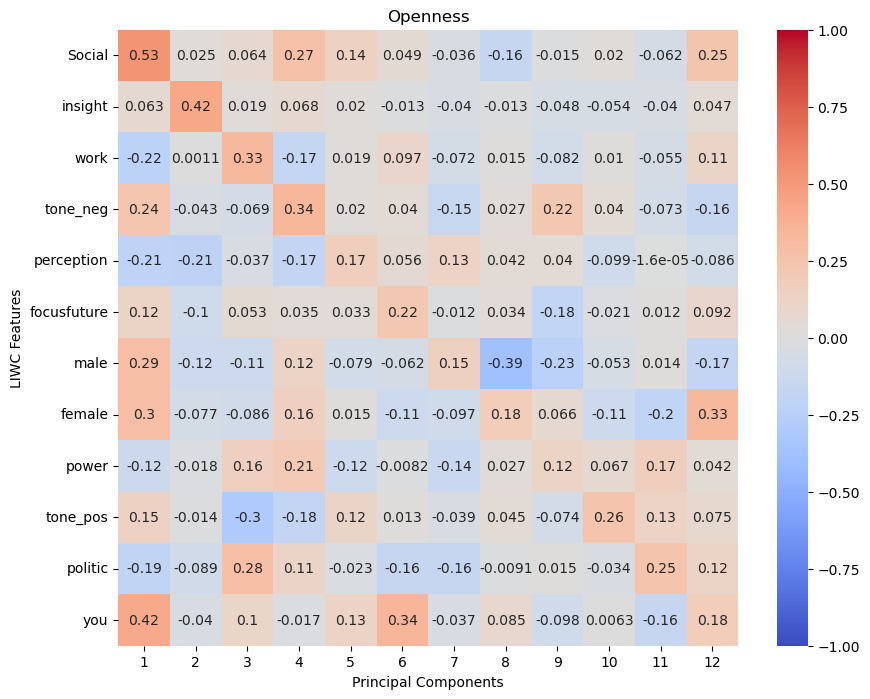

In [140]:
n_components = 12
savefig = True
for target in ['cOPN']:
   ldf = pd.read_csv(f'filter/{target}_ldf.csv')
   ldf = process_columns(ldf)

   lsdf = ldf [['Social', 'insight', 'work', 'tone_neg', 'perception', 'focusfuture', 'male', 'female', 'power','tone_pos', 'politic',  'you']]

   emb_np = np.load(f'filter/{target}_emb.npy') 
   eedf = pd.DataFrame(emb_np)
   print(eedf.shape, ldf.shape, target)

   pca = PCA(n_components=n_components)
   re = pca.fit_transform(eedf)
   redf = pd.DataFrame(re)
   redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

   final_df = pd.concat([lsdf, redf], axis=1)
   correlation_matrix = final_df.corr(method='pearson') 
   embedding_liwc_corr = correlation_matrix.loc[lsdf.columns, redf.columns]

   # emb_m  = add_float_to_matrix(embedding_liwc_corr, 0.1)
   plt.figure(figsize=(10, 8))
   sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
   # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
   plt.title(f'{traits[target]}')
   plt.xlabel(f'Principal Components')
   plt.ylabel(f'LIWC Features')
   # if savefig: plt.savefig(f'iteration/{target}_{n_components}_final.png', bbox_inches='tight')
   plt.show()

(2363, 1536) (2363, 147) cEXT


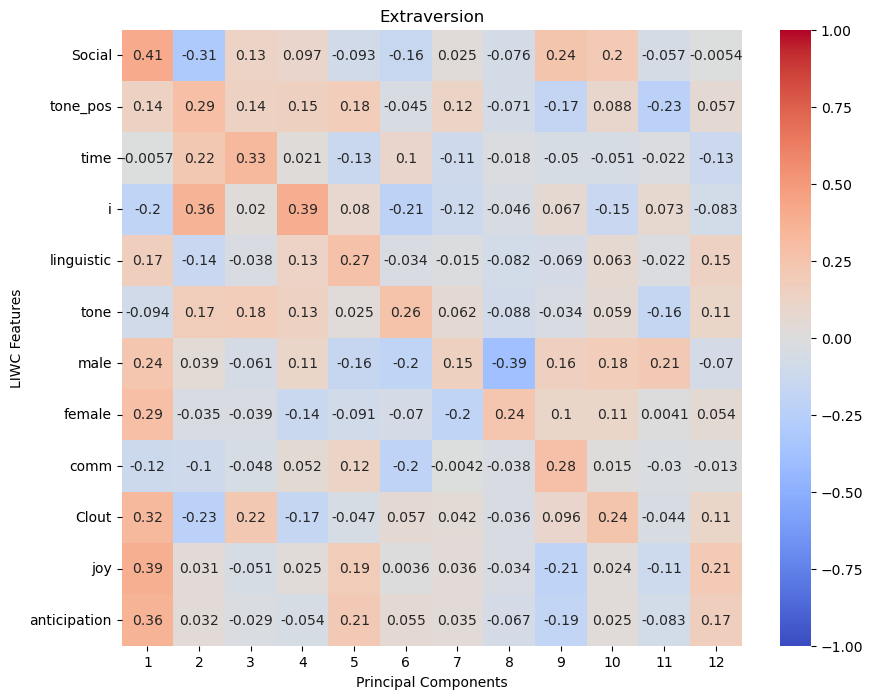

In [ ]:
n_components = 12
savefig = True
for target in ['cEXT']:
   ldf = pd.read_csv(f'filter/{target}_ldf.csv')
   ldf = process_columns(ldf)
   lsdf = ldf [['Social', 'tone_pos', 'time', 'i', 'linguistic', 'tone', 'male',  'female', 'comm', 'Clout', 'joy', 'anticipation',
   #   'cogproc', 'insight', 'cause', 'discrep', 'tentat', 'memory', 'attention', 'curiosity', 'anticipation', 'Cognition'
      # 'Social', 'socbehav', 'socrefs', 'affiliation', 'friend', 'family', 'polite', 'prosocial', 'comm', 'Conversation', 'trust', 'conflict', 'power', 'politic', 'ethnicity', 'shehe', 'they', 'we', 'you' 
      # 'WC', 'WPS', 'BigWords', 'Dic', 'function', 'pronoun', 'ppron', 'ipron', 'i', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'filler', 'nonflu', 'netspeak', 'swear', 'assent', 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' 
      # 'Drives', 'achieve', 'acquire', 'fulfill', 'reward', 'risk', 'need', 'want', 'lack', 'moral', 'power', 'affiliation', 'prosocial' , 'mental'
      # 'Perception', 'visual', 'auditory', 'motion', 'space', 'time'
      #   'physical':['Physical', 'health', 'wellness', 'illness', 'fatigue', 'food', 'substances', 'sexual', 'death' ],
      # 'Lifestyle', 'leisure', 'home', 'work', 'Culture', 'tech', 'money' 
      # 'Tone', 'Authentic', 'Analytic', 'Clout', 'sent_score', 'positive', 'negative', 'negate', 'allnone', 'certitude', 'tentat' 
      # 'focuspast', 'focuspresent', 'focusfuture',
      # 'Emoji', 'quantity', 'number', 'differ', 'allure', 'relig', 'female', 'male', 'politic', 'ethnicity', 'Affect'
      #  'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'pronoun', 'ppron', 'ipron', 'i', 'shehe', 'they', 'we', 'you'
      # 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP'
      # 'Analytic', 'Authentic', 'Clout', 'Tone', 'sent_score', 'Linguistic'
      # 'emo_anger', 'emo_anx', 'emo_neg', 'emo_pos', 'emo_sad', 'emotion', 'anger', 'fear', 'joy', 'sadness', 'disgust', 'surprise', 'tone_neg', 'tone_pos', 'feeling', 'Valence', 'Arousal' , 'Dominance'

   ]]

   emb_np = np.load(f'filter/{target}_emb.npy') 
   eedf = pd.DataFrame(emb_np)
   print(eedf.shape, ldf.shape, target)

   pca = PCA(n_components=n_components)
   re = pca.fit_transform(eedf)
   redf = pd.DataFrame(re)
   redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

   final_df = pd.concat([lsdf, redf], axis=1)
   correlation_matrix = final_df.corr(method='pearson') 
   embedding_liwc_corr = correlation_matrix.loc[lsdf.columns, redf.columns]

   plt.figure(figsize=(10, 8))
   sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
   # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
   plt.title(f'{traits[target]}')
   plt.xlabel(f'Principal Components')
   plt.ylabel(f'LIWC Features')
   if savefig: plt.savefig(f'iteration/{target}_{n_components}_final.png', bbox_inches='tight')
   plt.show()

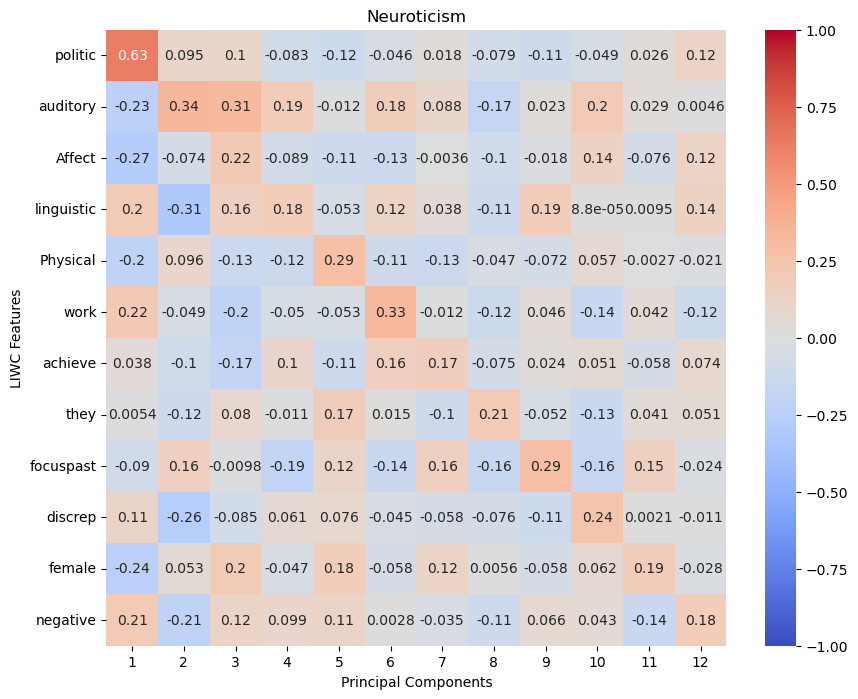

In [57]:
n_components = 12
for target in ['cNEU']:
   ldf = pd.read_csv(f'filter/{target}_ldf.csv')
   ldf = process_columns(ldf)
   lsdf = ldf [['politic', 'auditory', 'Affect', 'linguistic', 'Physical', 'work', 'achieve', 'they', 'focuspast','discrep',  'female',  'negative',
   #   'cogproc', 'insight', 'cause', 'discrep', 'tentat', 'memory', 'attention', 'curiosity', 'anticipation', 'Cognition'
      # 'Social', 'socbehav', 'socrefs', 'affiliation', 'friend', 'family', 'polite', 'prosocial', 'comm', 'Conversation', 'trust', 'conflict', 'power', 'politic', 'ethnicity', 'shehe', 'they', 'we', 'you' 
      # 'WC', 'WPS', 'BigWords', 'Dic', 'function', 'pronoun', 'ppron', 'ipron', 'i', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'filler', 'nonflu', 'netspeak', 'swear', 'assent', 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' 
      # 'Drives', 'achieve', 'acquire', 'fulfill', 'reward', 'risk', 'need', 'want', 'lack', 'moral', 'power', 'affiliation', 'prosocial' , 'mental'
      # 'Perception', 'visual', 'auditory', 'motion', 'space', 'time',
      # 'Physical', 'health', 'wellness', 'illness', 'fatigue', 'food', 'substances', 'sexual', 'death',
      # 'Lifestyle', 'leisure', 'home', 'work', 'Culture', 'tech', 'money' ,
      # 'Tone', 'Authentic', 'Analytic', 'Clout', 'sent_score', 'positive', 'negative', 'negate', 'allnone', 'certitude', 'tentat' 
      # 'focuspast', 'focuspresent', 'focusfuture',
      # 'Emoji', 'quantity', 'number', 'differ', 'allure', 'relig', 'female', 'male', 'politic', 'ethnicity', 'Affect'
      #  'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'pronoun', 'ppron', 'ipron', 'i', 'shehe', 'they', 'we', 'you'
      # 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP'
      # 'Analytic', 'Authentic', 'Clout', 'Tone', 'sent_score', 'Linguistic'
      # 'emo_anger', 'emo_anx', 'emo_neg', 'emo_pos', 'emo_sad', 'emotion', 'anger', 'fear', 'joy', 'sadness', 'disgust', 'surprise', 'tone_neg', 'tone_pos', 'feeling', 'Valence', 'Arousal' , 'Dominance'
      # 'Dominance', 'Arousal', 'Valence'
   ]]
   emb_np = np.load(f'filter/{target}_emb.npy') 
   eedf = pd.DataFrame(emb_np)
   pca = PCA(n_components=n_components)
   re = pca.fit_transform(eedf)
   redf = pd.DataFrame(re)
   redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

   final_df = pd.concat([lsdf, redf], axis=1)
   correlation_matrix = final_df.corr(method='pearson') 
   embedding_liwc_corr = correlation_matrix.loc[lsdf.columns, redf.columns]

   plt.figure(figsize=(10, 8))
   sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
   plt.title(f'{traits[target]}')
   plt.xlabel(f'Principal Components')
   plt.ylabel(f'LIWC Features')
   plt.savefig(f'iteration/{target}_{n_components}_final.png', bbox_inches='tight')
   plt.show()

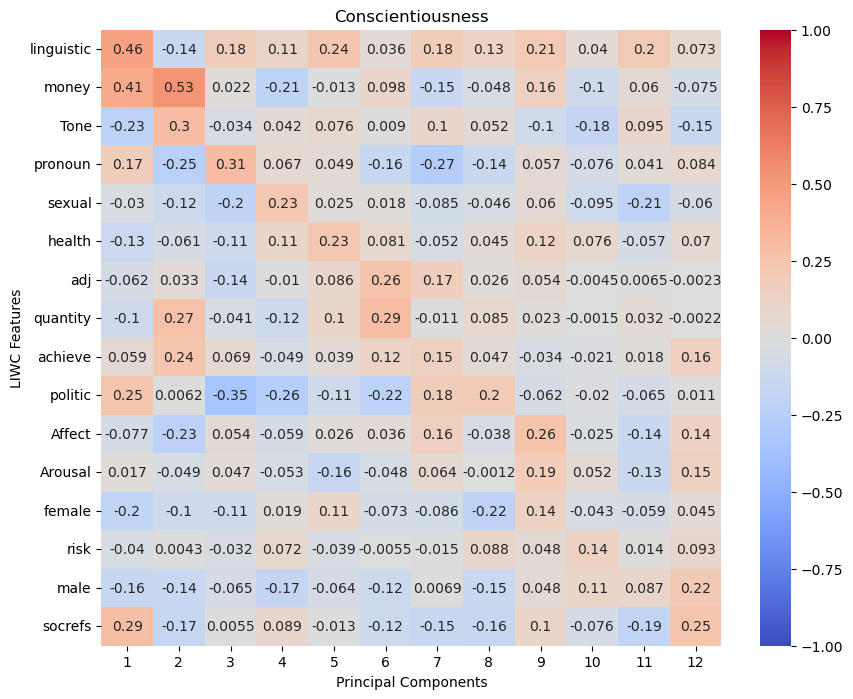

In [101]:
n_components = 12
for target in ['cCON']:
   ldf = pd.read_csv(f'filter/{target}_ldf.csv')
   ldf = process_columns(ldf)
   lsdf = ldf [[
    'linguistic', 'money', 'Tone', 'pronoun', 'sexual', 'health', 'adj', 'quantity', 'achieve', 'politic', 'Affect', 'Arousal', 'female', 'risk', 'male', 'socrefs',
    #  'cogproc', 'insight', 'cause', 'discrep', 'tentat', 'memory', 'attention', 'curiosity', 'anticipation', 'Cognition',
    #   'Social', 'socbehav', 'socrefs', 'affiliation', 'friend', 'family', 'polite', 'prosocial', 'comm', 'Conversation', 'trust', 'conflict', 'power', 'politic', 'ethnicity', 'shehe', 'they', 'we', 'you' ,
    #   'WC', 'WPS', 'BigWords', 'Dic', 'function', 'pronoun', 'ppron', 'ipron', 'i', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'filler', 'nonflu', 'netspeak', 'swear', 'assent', 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' ,
    #   'Drives', 'achieve', 'acquire', 'fulfill', 'reward', 'risk', 'need', 'want', 'lack', 'moral', 'power', 'affiliation', 'prosocial' , 'mental',
    #   'Perception', 'visual', 'auditory', 'motion', 'space', 'time',
    #   'Physical', 'health', 'wellness', 'illness', 'fatigue', 'food', 'substances', 'sexual', 'death',
    #   'Lifestyle', 'leisure', 'home', 'work', 'Culture', 'tech', 'money' ,
    #   'Tone', 'Authentic', 'Analytic', 'Clout', 'sent_score', 'positive', 'negative', 'negate', 'allnone', 'certitude', 'tentat' ,
    #   'focuspast', 'focuspresent', 'focusfuture',
    #   'Emoji', 'quantity', 'number', 'differ', 'allure', 'relig', 'female', 'male', 'politic', 'ethnicity', 'Affect',
    #    'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'pronoun', 'ppron', 'ipron', 'i', 'shehe', 'they', 'we', 'you',
    #   'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP',
    #   'Analytic', 'Authentic', 'Clout', 'Tone', 'sent_score', 'Linguistic',
    #   'emo_anger', 'emo_anx', 'emo_neg', 'emo_pos', 'emo_sad', 'emotion', 'anger', 'fear', 'joy', 'sadness', 'disgust', 'surprise', 'tone_neg', 'tone_pos', 'feeling', 
    #   'Dominance', 'Arousal', 'Valence'
   ]]
   emb_np = np.load(f'filter/{target}_emb.npy') 
   eedf = pd.DataFrame(emb_np)
   pca = PCA(n_components=n_components)
   re = pca.fit_transform(eedf)
   redf = pd.DataFrame(re)
   redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

   final_df = pd.concat([lsdf, redf], axis=1)
   correlation_matrix = final_df.corr(method='pearson') 
   embedding_liwc_corr = correlation_matrix.loc[lsdf.columns, redf.columns]

   plt.figure(figsize=(10, 8))
   sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
   plt.title(f'{traits[target]}')
   plt.xlabel(f'Principal Components')
   plt.ylabel(f'LIWC Features')
   plt.savefig(f'iteration/{target}_{n_components}_final.png', bbox_inches='tight')
   plt.show()

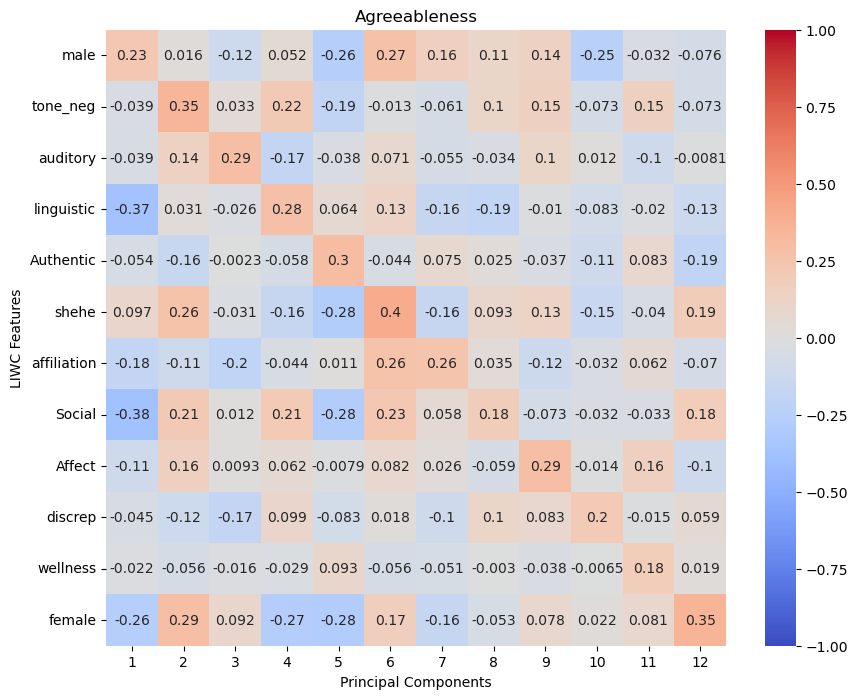

In [20]:
n_components = 12
for target in ['cAGR']:
   ldf = pd.read_csv(f'filter/{target}_ldf.csv')
   ldf = process_columns(ldf)
   lsdf = ldf [[
    'male', 'tone_neg' ,'auditory', 'linguistic', 'Authentic', 'shehe', 'affiliation', 'Social',  'Affect',  'discrep',  'wellness', 'female',
   #   'cogproc', 'insight', 'cause', 'discrep', 'tentat', 'memory', 'attention', 'curiosity', 'anticipation', 'Cognition',
      # 'Social', 'socbehav', 'socrefs', 'affiliation', 'friend', 'family', 'polite', 'prosocial', 'comm', 'Conversation', 'trust', 'conflict', 'power', 'politic', 'ethnicity', 'shehe', 'they', 'we', 'you' ,
    #   'WC', 'WPS', 'BigWords', 'Dic', 'function', 'pronoun', 'ppron', 'ipron', 'i', 'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'filler', 'nonflu', 'netspeak', 'swear', 'assent', 'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP' ,
      # 'Drives', 'achieve', 'acquire', 'fulfill', 'reward', 'risk', 'need', 'want', 'lack', 'moral', 'power', 'affiliation', 'prosocial' , 'mental',
    #   'Perception', 'visual', 'auditory', 'motion', 'space', 'time',
      # 'Physical', 'health', 'wellness', 'illness', 'fatigue', 'food', 'substances', 'sexual', 'death',
    #   'Lifestyle', 'leisure', 'home', 'work', 'Culture', 'tech', 'money' ,
    #   'Tone', 'Authentic', 'Analytic', 'Clout', 'sent_score', 'positive', 'negative', 'negate', 'allnone', 'certitude', 'tentat' ,
    #   'focuspast', 'focuspresent', 'focusfuture',
    #   'Emoji', 'quantity', 'number', 'differ', 'allure', 'relig', 'female', 'male', 'politic', 'ethnicity', 'Affect',
    #    'verb', 'adj', 'adverb', 'article', 'prep', 'conj', 'auxverb', 'det', 'pronoun', 'ppron', 'ipron', 'i', 'shehe', 'they', 'we', 'you',
    #   'AllPunc', 'Apostro', 'Comma', 'Exclam', 'Period', 'QMark', 'OtherP',
    #   'Analytic', 'Authentic', 'Clout', 'Tone', 'sent_score', 'Linguistic',
      # 'emo_anger', 'emo_anx', 'emo_neg', 'emo_pos', 'emo_sad', 'emotion', 'anger', 'fear', 'joy', 'sadness', 'disgust', 'surprise', 'tone_neg', 'tone_pos', 'feeling', 
    #   'Dominance', 'Arousal', 'Valence'
   ]]
   emb_np = np.load(f'filter/{target}_emb.npy') 
   eedf = pd.DataFrame(emb_np)
   pca = PCA(n_components=n_components)
   re = pca.fit_transform(eedf)
   redf = pd.DataFrame(re)
   redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

   final_df = pd.concat([lsdf, redf], axis=1)
   correlation_matrix = final_df.corr(method='pearson') 
   embedding_liwc_corr = correlation_matrix.loc[lsdf.columns, redf.columns]

   plt.figure(figsize=(10, 8))
   sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
   plt.title(f'{traits[target]}')
   plt.xlabel(f'Principal Components')
   plt.ylabel(f'LIWC Features')
   plt.savefig(f'iteration/{target}_{n_components}_final.png', bbox_inches='tight')
   plt.show()

Highly Important LIWC Features: ['WC', 'Analytic', 'Clout', 'Authentic', 'Tone', 'BigWords', 'tech', 'AllPunc', 'OtherP']


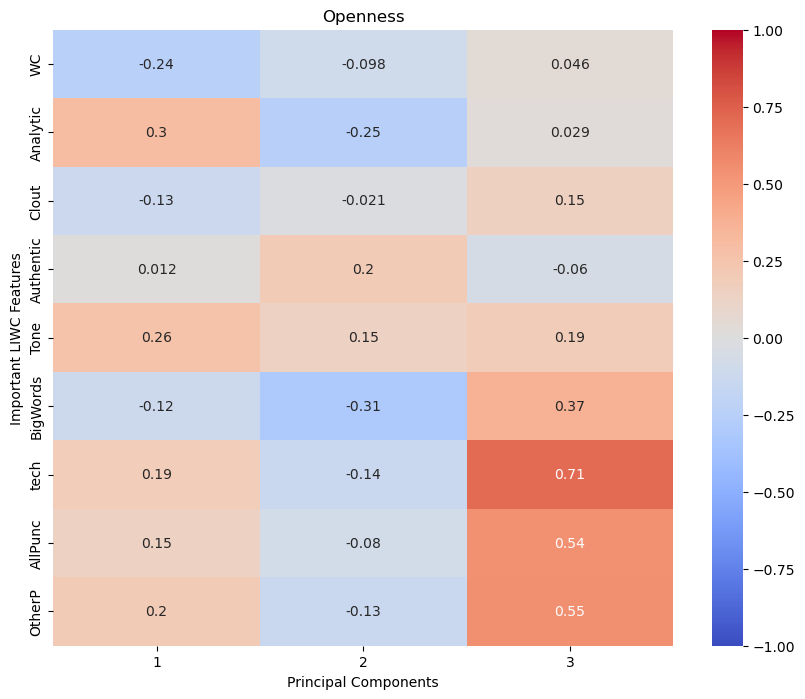

Highly Important LIWC Features: ['WC', 'Authentic', 'Tone', 'Dic', 'Social', 'focuspast']


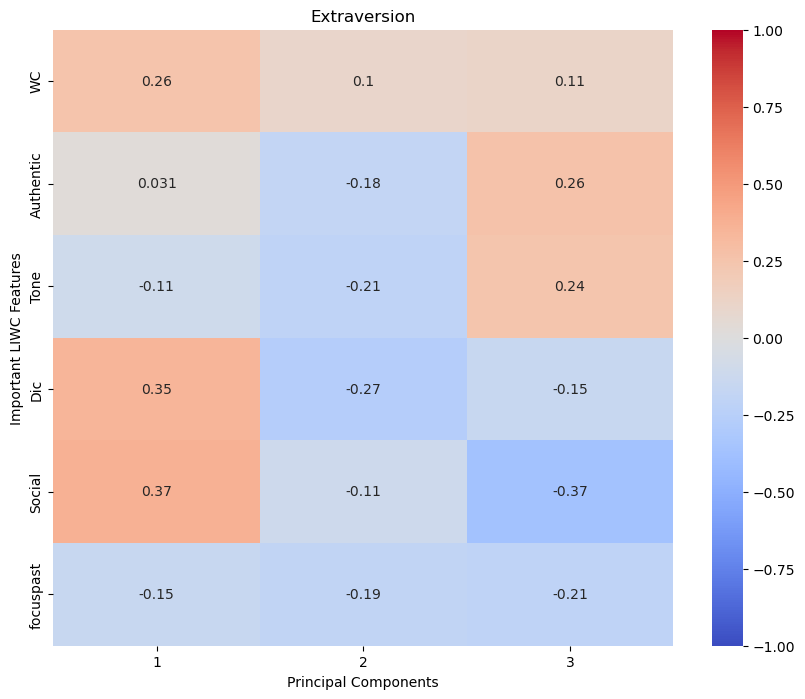

Highly Important LIWC Features: ['WC', 'Clout', 'Authentic', 'Tone', 'WPS', 'BigWords', 'Culture', 'tech', 'AllPunc', 'OtherP']


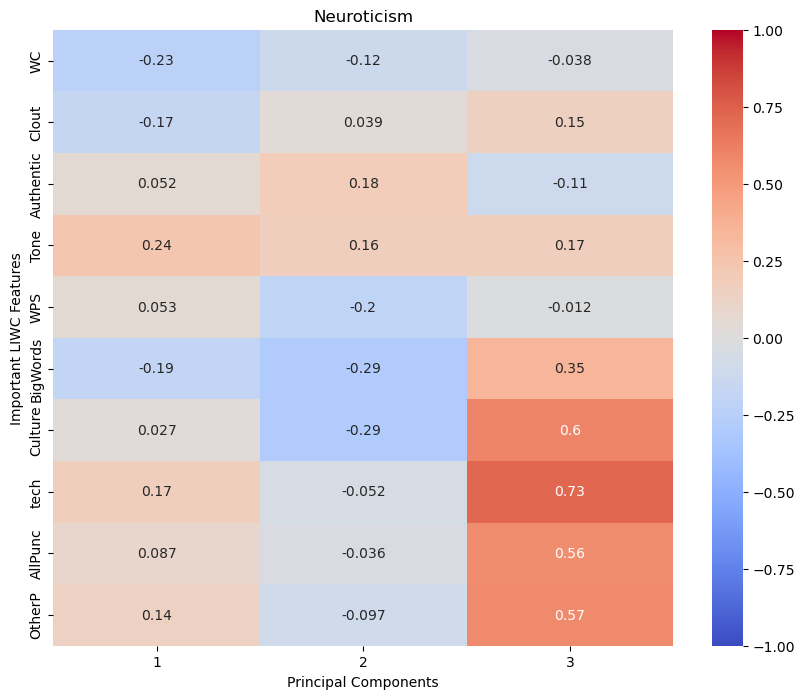

Highly Important LIWC Features: ['WC', 'Analytic', 'Clout', 'Authentic', 'Tone', 'BigWords', 'you', 'tech', 'AllPunc', 'OtherP']


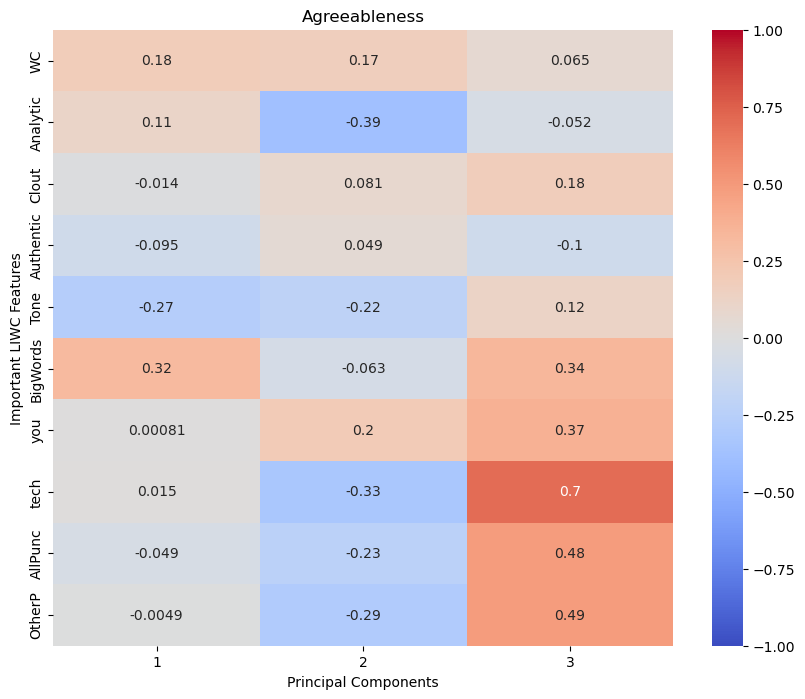

Highly Important LIWC Features: ['WC', 'Analytic', 'Clout', 'Authentic', 'WPS', 'cogproc', 'focuspast']


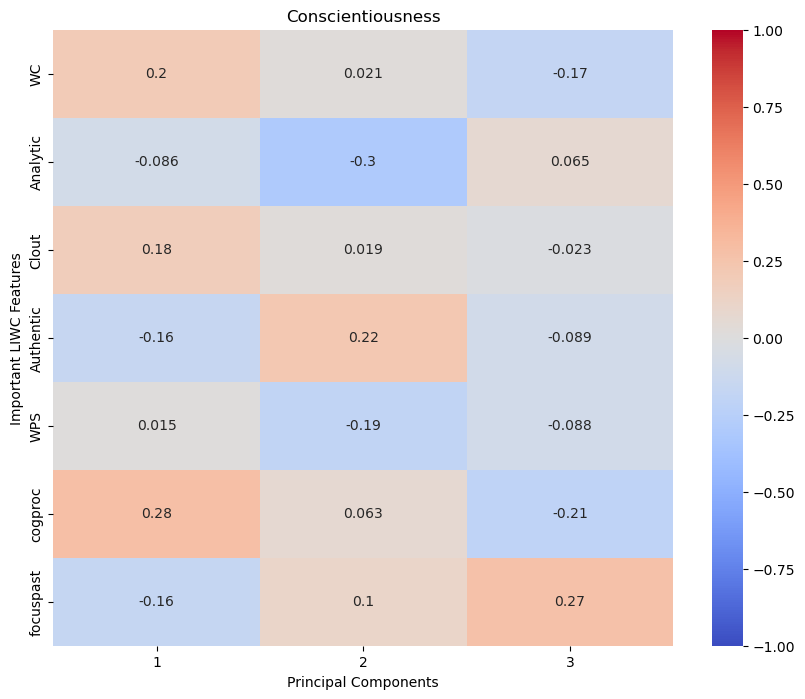

In [ ]:
pca_map = { 'cOPN': 2, 'cEXT': 3, 'cNEU': 5, 'cAGR': 3, 'cCON': 2}
n_components = 3
trait_features ={}
pca_dim = 3
lasso_alpha = 0.1
savefig = True

for target in ['cOPN']:
    ldf = pd.read_csv(f'data/{target}_ldf.csv')
    ldf = ldf.loc[:, ~ldf.columns.str.contains('^Unnamed')]
    ldf = ldf [['Analytic', 'Clout', 'Tone', 'WPS', 'BigWords', 'Dic', 'Linguistic',
       'function', 'pronoun', 'ppron', 'i', 'we', 'you', 'shehe', 'they',
       'ipron', 'article', 'number', 'prep', 'auxverb', 'conj', 'negate',
       'verb', 'adj', 'quantity', 'Drives', 'affiliation', 'achieve', 'power',
       'Cognition', 'allnone', 'cogproc', 'cause', 'discrep', 'tentat',
       'memory', 'Affect', 'tone_pos', 'tone_neg', 'emotion', 'emo_pos',
       'emo_neg', 'emo_anx', 'swear', 'Social', 'socbehav', 'prosocial',
       'socrefs', 'friend', 'female', 'male', 'Culture', 'politic',
       'ethnicity', 'tech', 'leisure', 'work', 'money', 'relig', 'illness',
       'acquire', 'lack', 'fatigue', 'curiosity', 'Perception', 'motion',
       'space', 'visual', 'auditory', 'feeling', 'focuspast', 'focuspresent',
       'focusfuture', 'Conversation', 'netspeak', 'assent', 'nonflu', 'filler',
       'AllPunc', 'Period', 'Comma', 'QMark', 'Exclam', 'Apostro', 'OtherP',
       'anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative',
       'surprise', 'trust', 'Valence', 'Dominance', 'sent_score']]
    # ldf = process_columns(ldf)

    emb_np = np.load(f'data/{target}_emb.npy') 
    eedf = pd.DataFrame(emb_np)

    pca = PCA(n_components=n_components)
    re = pca.fit_transform(eedf)
    redf = pd.DataFrame(re)
    redf.columns = [f'{i+1}' for i in range(redf.shape[1])]

    X = np.array(ldf)  
    y = np.array(redf)  
    lasso = Lasso(alpha=lasso_alpha)  
    lasso.fit(X, y[:, 0])  
    coefficients = lasso.coef_
    key_features = []
    for i in range(y.shape[1]):
        lasso = Lasso(alpha=lasso_alpha) 
        lasso.fit(X, y[:, i])
        coefficients = lasso.coef_
        key_features.append(coefficients)

    liwc_feature_names = ldf.columns
    highly_important_indices = np.where(np.abs(coefficients) != 0)[0]
    highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]
    print("Highly Important LIWC Features:", highly_important_features)

    # plt.figure(figsize=(10, 5))
    # plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
    # plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
    # plt.xlabel("LIWC Features")
    # plt.ylabel("Coefficient Value")
    # # plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
    # # plt.title(f'{traits[target]}')
    # if savefig: plt.savefig(f'corre/{target}_liwc.png', bbox_inches='tight')
    # plt.show()

    # trait_features[target] = highly_important_features
    # pca = PCA(n_components=None)
    # pca.fit(ldf[highly_important_features])
    # plt.plot(pca.explained_variance_ratio_, marker='o')
    # plt.xlabel('Principal Component')
    # plt.ylabel('Explained Variance Ratio')
    # # plt.title('Scree Plot')
    # if savefig: plt.savefig(f'corre/{target}_scree.png', bbox_inches='tight')
    # plt.show()

    final_df = pd.concat([ldf[highly_important_features], redf], axis=1)
    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
    plt.title(f'{traits[target]}')
    plt.xlabel(f'Principal Components')
    plt.ylabel(f'Important LIWC Features')
    # if savefig: plt.savefig(f'iteration/{target}_{n_components}.png', bbox_inches='tight')
    plt.show()

(20333, 1536) (20333, 134) cOPN
Highly Important LIWC Features: ['BigWords', 'i', 'you', 'shehe', 'number', 'adj', 'achieve', 'power', 'polite', 'conflict', 'comm', 'tech', 'leisure', 'sexual', 'death', 'reward', 'curiosity', 'attention', 'focuspresent', 'netspeak', 'AllPunc', 'OtherP', 'Arousal', 'Dominance']


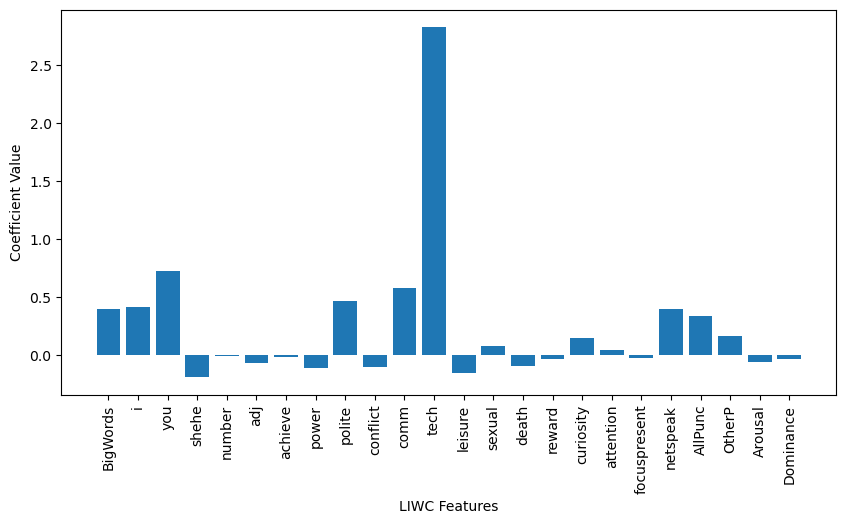

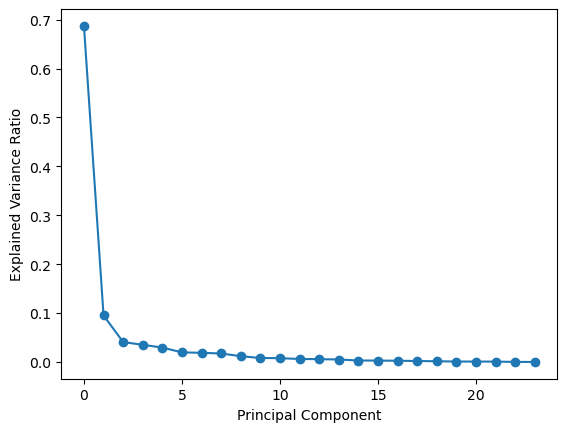

(24026, 1536) (24026, 134) cEXT
Highly Important LIWC Features: ['WC', 'Authentic', 'BigWords', 'Dic', 'i', 'you', 'shehe', 'article', 'negate', 'affiliation', 'power', 'cogproc', 'insight', 'tone_neg', 'Social', 'socrefs', 'family', 'female', 'male', 'politic', 'tech', 'work', 'sexual', 'death', 'curiosity', 'focuspast', 'AllPunc', 'OtherP', 'Valence', 'Arousal', 'sent_score']


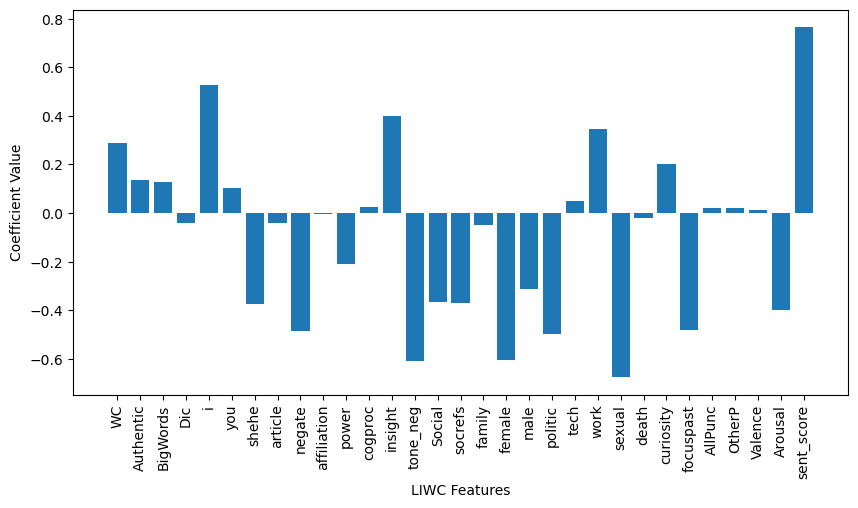

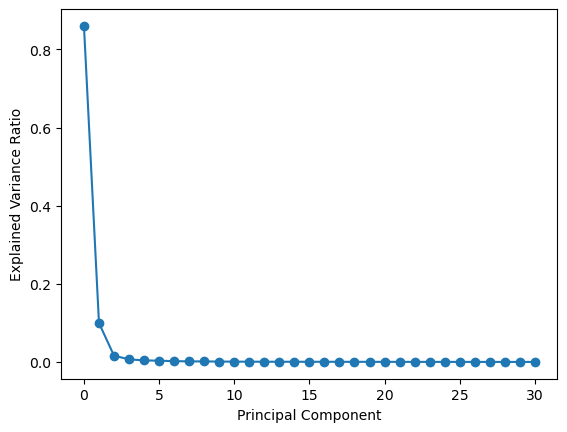

(19952, 1536) (19952, 134) cNEU
Highly Important LIWC Features: ['WPS', 'BigWords', 'you', 'conj', 'adj', 'achieve', 'Social', 'socbehav', 'polite', 'comm', 'Culture', 'tech', 'money', 'curiosity', 'focuspast', 'netspeak', 'AllPunc', 'Period', 'Dominance']


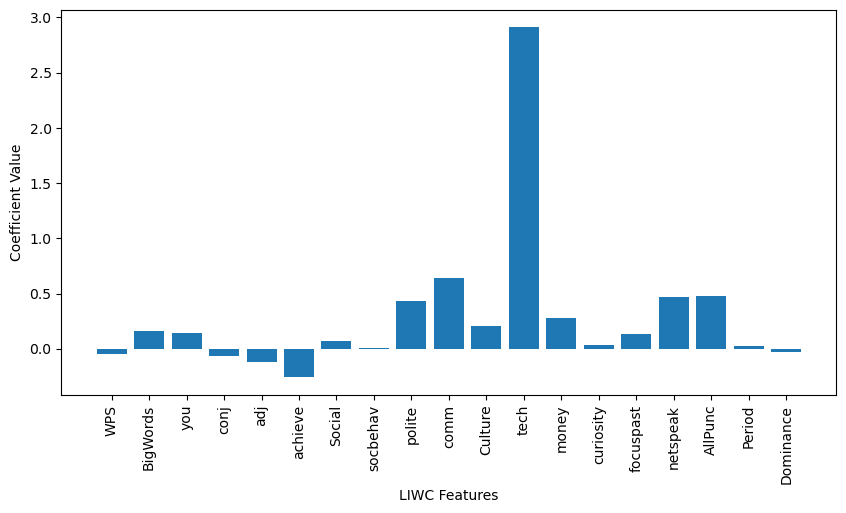

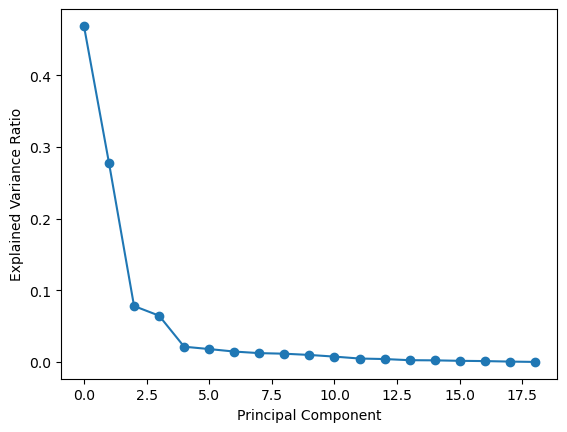

(19830, 1536) (19830, 134) cAGR
Highly Important LIWC Features: ['Dic', 'you', 'they', 'negate', 'adj', 'insight', 'discrep', 'Social', 'socbehav', 'prosocial', 'polite', 'Culture', 'tech', 'leisure', 'money', 'Physical', 'sexual', 'AllPunc', 'disgust', 'sent_score']


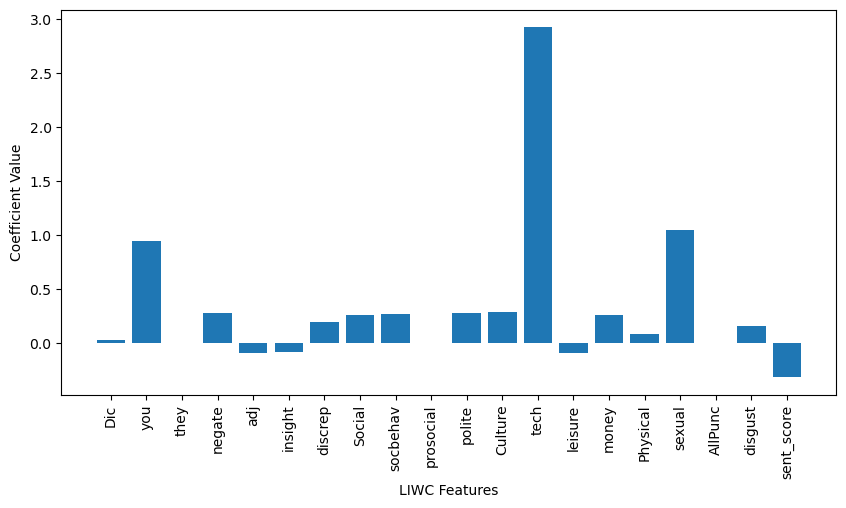

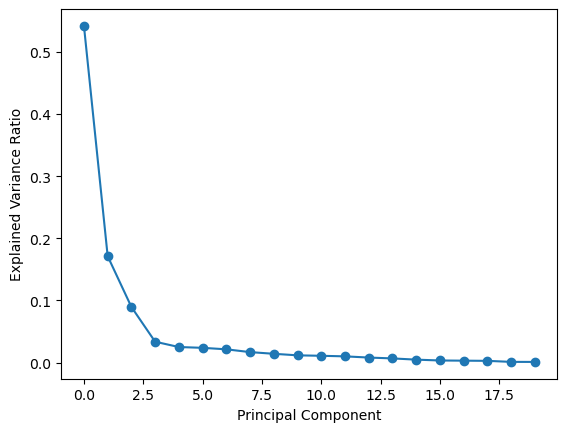

(24591, 1536) (24591, 134) cCON
Highly Important LIWC Features: ['WC', 'WPS', 'i', 'you', 'shehe', 'article', 'achieve', 'cogproc', 'cause', 'discrep', 'certitude', 'Affect', 'tone_neg', 'swear', 'Social', 'moral', 'female', 'Culture', 'politic', 'ethnicity', 'leisure', 'work', 'health', 'wellness', 'need', 'visual', 'auditory', 'focuspast', 'Conversation']


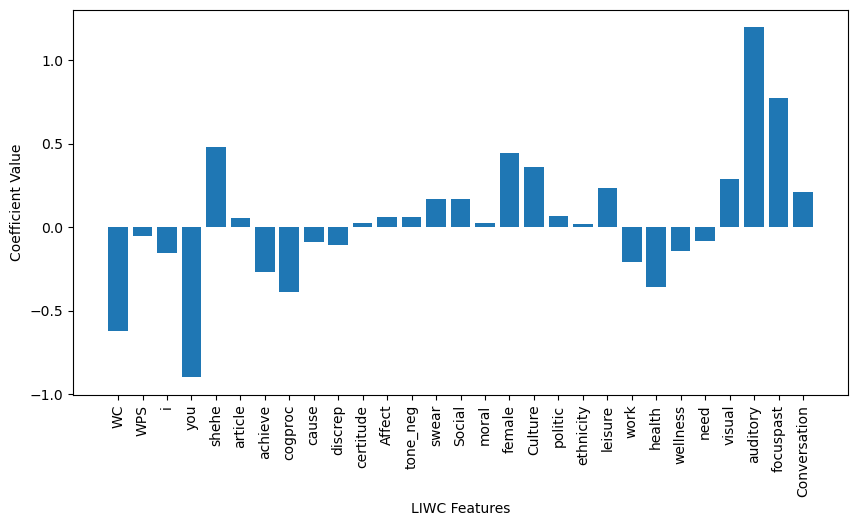

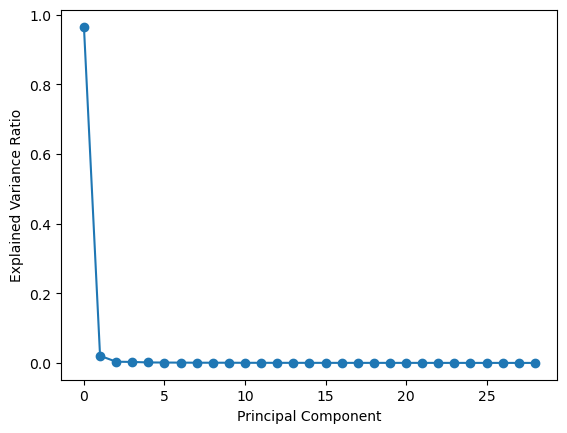

In [ ]:
pca_dim = 3
lasso_alpha = 0.3
savefig = True

for target in traits:
    
    ldf = pd.read_csv(f'data/{target}_ldf.csv')
    emb_np = np.load(f'data/{target}_emb.npy') 
    eedf = pd.DataFrame(emb_np)
    eedf.columns = [f'e_{i}' for i in range(1536)]

    scaler = StandardScaler()
    esdf = scaler.fit_transform(eedf)
    lsdf = scaler.fit_transform(ldf)
    print(eedf.shape, ldf.shape, target)

    pca = PCA(n_components=pca_dim)
    re = pca.fit_transform(esdf)
    redf = pd.DataFrame(re)
    redf.columns = [f'pca_{i}' for i in range(redf.shape[1])]

    X = np.array(lsdf)  
    y = np.array(redf)  
    lasso = Lasso(alpha=lasso_alpha)  
    lasso.fit(X, y[:, 0])  
    coefficients = lasso.coef_
    key_features = []

    for i in range(y.shape[1]):
        lasso = Lasso(alpha=lasso_alpha) 
        lasso.fit(X, y[:, i])
        coefficients = lasso.coef_
        key_features.append(coefficients)

    liwc_feature_names = ldf.columns

    # Assuming `coefficients` is the array of Lasso coefficients
    highly_important_indices = np.where(np.abs(coefficients) != 0)[0]
    highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]
    print("Highly Important LIWC Features:", highly_important_features)

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
    plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
    plt.xlabel("LIWC Features")
    plt.ylabel("Coefficient Value")
    # plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
    # plt.title(f'{traits[target]}')
    if savefig: plt.savefig(f'corre/{target}_liwc.png', bbox_inches='tight')
    plt.show()

    trait_features[target] = highly_important_features
    pca = PCA(n_components=None)
    pca.fit(ldf[highly_important_features])
    plt.plot(pca.explained_variance_ratio_, marker='o')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    # plt.title('Scree Plot')
    if savefig: plt.savefig(f'corre/{target}_scree.png', bbox_inches='tight')
    plt.show()

In [ ]:
# pca_dim = 3
# lasso_alpha = 0.3
# savefig = True

# for target in traits:
#     ldf = pd.read_csv(f'data/{target}_ldf.csv')
#     emb_np = np.load(f'data/{target}_emb.npy') 
#     eedf = pd.DataFrame(emb_np)
#     eedf.columns = [f'e_{i}' for i in range(1536)]

#     scaler = StandardScaler()
#     esdf = scaler.fit_transform(eedf)
#     lsdf = scaler.fit_transform(ldf)
#     print(eedf.shape, ldf.shape, target)

#     pca = PCA(n_components=pca_map[target])
#     re = pca.fit_transform(esdf)
#     redf = pd.DataFrame(re)
#     redf.columns = [f'pca_{i}' for i in range(redf.shape[1])]
#     X = np.array(lsdf)  
#     y = np.array(redf)  
#     lasso = Lasso(alpha=lasso_alpha)  
#     lasso.fit(X, y[:, 0])  
#     coefficients = lasso.coef_
#     key_features = []

#     for i in range(y.shape[1]):
#         lasso = Lasso(alpha=lasso_alpha) 
#         lasso.fit(X, y[:, i])
#         coefficients = lasso.coef_
#         key_features.append(coefficients)

#     liwc_feature_names = ldf.columns

#     # Assuming `coefficients` is the array of Lasso coefficients
#     highly_important_indices = np.where(np.abs(coefficients) != 0)[0]
#     highly_important_features = [liwc_feature_names[i] for i in highly_important_indices]
#     print("Highly Important LIWC Features:", highly_important_features)

#     plt.figure(figsize=(10, 5))
#     plt.bar(range(len(highly_important_indices)), coefficients[highly_important_indices])
#     plt.xticks(range(len(highly_important_indices)), [liwc_feature_names[i] for i in highly_important_indices], rotation=90)
#     plt.xlabel("LIWC Features")
#     plt.ylabel("Coefficient Value")
#     # plt.title(f"{traits[target]}: Highly Important LIWC Features (Lasso Coefficients)")
#     # plt.title(f'{traits[target]}')
#     if savefig: plt.savefig(f'corre/{target}_liwc.png', bbox_inches='tight')
#     plt.show()

#     # pca = PCA(n_components=None)
#     # pca.fit(ldf[highly_important_features])
#     # plt.plot(pca.explained_variance_ratio_, marker='o')
#     # plt.xlabel('Principal Component')
#     # plt.ylabel('Explained Variance Ratio')
#     # plt.title('Scree Plot')
#     # if savefig: plt.savefig(f'corre/{target}_stree.png', bbox_inches='tight')
#     # plt.show()

#     # highly_important_features = summary_variables
#     final_df = pd.concat([ldf[trait_features[tar]], redf], axis=1)
#     # Compute correlation matrix
#     correlation_matrix = final_df.corr(method='pearson') 
#     embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


#     plt.figure(figsize=(10, 8))
#     sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
#     # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
#     # plt.title(f'{traits[target]}')
#     plt.xlabel(f'Principal Components')
#     plt.ylabel(f'Important LIWC Features')
#     if savefig: plt.savefig(f'corre/{target}.png', bbox_inches='tight')
#     plt.show()

In [16]:
dimensions = {
'summary_variables' : [ "WC", "Analytic", "Clout", "Authentic", "Tone", "WPS", "BigWords", "Dic"],
'linguistic_dimensions' : ["Linguistic", "function", "pronoun", "ppron", "i", "we", "you", "shehe", "they", "ipron", "det", "article", "number", "prep", "auxverb", "adverb", "conj", "negate", "verb", "adj", "quantity"],
'psychological_process' :  ["Drives", "affiliation", "achieve", "power", "Cognition", "allnone", "cogproc", "insight", "cause", "discrep", "tentat", "certitude", "differ", "memory", "Affect", "tone_pos", "tone_neg", "emotion", "emo_pos", "emo_neg", "emo_anx", "emo_anger", "emo_sad", "swear", "Social", "socbehav", "prosocial", "polite", "conflict", "moral", "comm", "socrefs", "family", "friend", "female", "male"],
'expanded_dictionary' :  ["Culture", "politic", "ethnicity", "tech", "Lifestyle", "leisure", "home", "work", "money", "relig", "Physical", "health", "illness", "wellness", "mental", "substances", "sexual", "food", "death", "need", "want", "acquire", "lack", "fulfill", "fatigue", "reward", "risk", "curiosity", "allure", "Perception", "attention", "motion", "space", "visual", "auditory", "feeling", "time", "focuspast", "focuspresent", "focusfuture", "Conversation", "netspeak", "assent", "nonflu", "filler",  "AllPunc", "Period", "Comma", "QMark", "Exclam", "Apostro", "OtherP", "Emoji"],
'emotions' : [ "anger", "anticipation", "disgust", "fear", "joy", "negative", "positive", "sadness", "surprise", "trust"],
'VAD' : ["Valence", "Arousal", "Dominance", "sent_score"]
}

In [ ]:
for v in dimensions.values():
    highly_important_features = v
    final_df = pd.concat([ldf[highly_important_features], redf], axis=1)
    # Compute correlation matrix
    correlation_matrix = final_df.corr(method='pearson') 
    embedding_liwc_corr = correlation_matrix.loc[highly_important_features, redf.columns]


    plt.figure(figsize=(10, 8))
    sns.heatmap(embedding_liwc_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    # plt.title(f"{traits[target]} Correlation between Reduced Embeddings and LIWC Features")
    plt.title(f'{traits[target]}')
    if savefig: plt.savefig(f'output/{target}.png', bbox_inches='tight')
    plt.show()